# LoRA 角色扮演微调 — Phi-3.5-mini-instruct + QLoRA

**硬件:** RTX 4060 Laptop 8GB VRAM  
**模型:** Phi-3.5-mini-instruct (3.8B)  
**数据集:** amaydle/npc-dialogue (~1.7K 条 NPC 对话)  
**方法:** QLoRA (4-bit NF4 量化 + LoRA)

与 Qwen 版的区别:
- Phi-3.5 用 `<|system|>/<|user|>/<|assistant|><|end|>` 格式
- LoRA target 模块为 `qkv_proj, o_proj, gate_up_proj, down_proj`
- npc-dialogue 是单轮 Q&A 数据集（Biography → Query → Response）

## 1. 环境检查

虚拟环境 `.venv` 已预先创建（PyTorch cu124 + 全部依赖）。

> 如果还未切换 kernel：右上角选择 `Python (roleplay-lora)`，然后运行本 cell。

In [1]:
import sys, os
from pathlib import Path
import torch

# -- 必须在任何 HuggingFace 相关导入之前设置镜像 --
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
print("HF 镜像: hf-mirror.com")

# -- 确认在正确的虚拟环境中 --
VENV_DIR = Path.cwd() / ".venv"
in_venv = str(VENV_DIR) in sys.prefix or str(VENV_DIR) in sys.executable
print(f"Python: {sys.executable}")
if not in_venv:
    print("⚠️  当前不在 .venv 中，请切换到 Python (roleplay-lora) kernel 后重试")
else:
    print("✅ 虚拟环境: OK")

# -- 检查 GPU --
print(f"PyTorch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}  |  cuDNN: {torch.version.cuda}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}  |  显存: {props.total_memory / (1024**3):.1f} GB")
    assert props.total_memory / (1024**3) >= 7.5, f"显存不足"
else:
    raise RuntimeError("CUDA 不可用，请确认已切换到 Python (roleplay-lora) kernel")

HF 镜像: hf-mirror.com
Python: /home/arccc/Roleplay/.venv/bin/python
✅ 虚拟环境: OK
PyTorch: 2.6.0+cu124  |  CUDA: True  |  cuDNN: 12.4
GPU: NVIDIA GeForce RTX 4060 Laptop GPU  |  显存: 8.0 GB


## 2. 配置参数

In [2]:
import os
from datetime import datetime

# ========== 模型配置 ==========
MODEL_NAME = "microsoft/Phi-3.5-mini-instruct"  # 3.8B 参数

# ========== 数据集配置 ==========
DATASET_NAME = "amaydle/npc-dialogue"             # ~1.7K 条 NPC 对话
MAX_SEQ_LENGTH = 512

# ========== QLoRA 配置 ==========
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05
# Phi-3.5 的 linear 层命名: qkv_proj (合并QKV), o_proj, gate_up_proj, down_proj
LORA_TARGET_MODULES = [
    "qkv_proj", "o_proj",
    "gate_up_proj", "down_proj",
]

# ========== 训练配置 ==========
OUTPUT_DIR = "./roleplay-lora-extra"
BATCH_SIZE = 1
GRADIENT_ACCUMULATION = 8
LEARNING_RATE = 2e-4
NUM_EPOCHS = 3
WARMUP_STEPS = 50
LOGGING_STEPS = 5
SAVE_STEPS = 100
SAVE_TOTAL_LIMIT = 2

# ========== 日志 ==========
LOG_DIR = "./roleplay-lora-extra/logs/20260610-161441"
# LOG_DIR = os.path.join(OUTPUT_DIR, "logs", datetime.now().strftime("%Y%m%d-%H%M%S"))

print(f"输出目录: {OUTPUT_DIR}")
print(f"日志目录: {LOG_DIR}")
print(f"显存估算: Phi-3.5-mini ~2.5GB(4-bit) + LoRA + 激活值 ≈ 5-6GB | 安全 ✓")

输出目录: ./roleplay-lora-extra
日志目录: ./roleplay-lora-extra/logs/20260610-161441
显存估算: Phi-3.5-mini ~2.5GB(4-bit) + LoRA + 激活值 ≈ 5-6GB | 安全 ✓


## 3. 加载并格式化数据集

amaydle/npc-dialogue 字段: `Name`, `Biography`, `Query`, `Response`, `Emotion`。
每一行是一条单轮 NPC 对话，需要用 Phi-3.5 的 chat template 格式化。

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token  # Phi-3.5 用 <|endoftext|> 作 EOS/PAD

print(f"Tokenizer vocab: {len(tokenizer)}")
print(f"Chat template 前 200 字符: {tokenizer.chat_template[:200] if tokenizer.chat_template else 'None'}...")

# 加载原始数据集
raw_dataset = load_dataset(DATASET_NAME, split="train")
print(f"数据集大小: {len(raw_dataset)}")
print(f"字段: {raw_dataset.column_names}")
print(f"\n--- 样本预览 ---")
print(f"  Name: {raw_dataset[0]['Name']}")
print(f"  Biography: {raw_dataset[0]['Biography'][:150]}...")
print(f"  Query: {raw_dataset[0]['Query']}")
print(f"  Response: {raw_dataset[0]['Response']}")
print(f"  Emotion: {raw_dataset[0]['Emotion']}")

/home/arccc/Roleplay/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tokenizer vocab: 32011
Chat template 前 200 字符: {% for message in messages %}{% if message['role'] == 'system' and message['content'] %}{{'<|system|>
' + message['content'] + '<|end|>
'}}{% elif message['role'] == 'user' %}{{'<|user|>
' + message['...
数据集大小: 1723
字段: ['Name', 'Biography', 'Query', 'Response', 'Emotion']

--- 样本预览 ---
  Name: Bikram
  Biography: Bikram is a rough and tough smuggler from the streets of Calcutta, India....
  Query: What is your opinion on friendship?
  Response: Friendship is a bond stronger than blood.
  Emotion: Loyalty


In [4]:
def format_conversation(example):
    """
    npc-dialogue 是单轮对话:
      - system: Biography (NPC 角色描述)
      - user: Query (玩家提问)
      - assistant: Response (NPC 回复)
    
    使用 Phi-3.5 的 chat template 转为训练文本。
    Phi-3.5 格式: <|system|>...<|end|><|user|>...<|end|><|assistant|>...<|end|>
    """
    messages = [
        {"role": "system", "content": example["Biography"]},
        {"role": "user", "content": example["Query"]},
        {"role": "assistant", "content": example["Response"]},
    ]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )
    return {"text": text}


print("正在格式化数据集...")
# 保留需要的列
formatted_dataset = raw_dataset.map(
    format_conversation,
    remove_columns=raw_dataset.column_names,
)

sample = formatted_dataset[0]["text"]
print(f"格式化样本数: {len(formatted_dataset)}")
print(f"\n--- Phi-3.5 格式化样本 ---")
print(sample[:400])

正在格式化数据集...
格式化样本数: 1723

--- Phi-3.5 格式化样本 ---
<|system|>
Bikram is a rough and tough smuggler from the streets of Calcutta, India.<|end|>
<|user|>
What is your opinion on friendship?<|end|>
<|assistant|>
Friendship is a bond stronger than blood.<|end|>
<|endoftext|>


In [5]:
# 划分 train/eval（9:1），SFTTrainer 会在训练时自动 tokenize
split_dataset = formatted_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

print(f"训练集: {len(train_dataset)} 条  |  验证集: {len(eval_dataset)} 条")
print(f"等效 batch size: {BATCH_SIZE} × {GRADIENT_ACCUMULATION} = {BATCH_SIZE * GRADIENT_ACCUMULATION}")
print(f"预计步数/epoch: ~{len(train_dataset) // (BATCH_SIZE * GRADIENT_ACCUMULATION)}")

训练集: 1550 条  |  验证集: 173 条
等效 batch size: 1 × 8 = 8
预计步数/epoch: ~193


## 4. 加载模型 (4-bit QLoRA)

Phi-3.5-mini-instruct ~3.8B 参数，4-bit 后约 2.5GB。

In [6]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

print(f"正在加载模型: {MODEL_NAME}")
print("首次加载会从 HuggingFace 下载 ~7.6GB 权重（压缩后 ~3.8GB），请耐心等待...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.bfloat16,
    trust_remote_code=True,
)

model.config.use_cache = False

mem_used = torch.cuda.memory_allocated() / (1024**3)
print(f"显存使用: {mem_used:.2f} GB")
print(f"总参数量: {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M")

正在加载模型: microsoft/Phi-3.5-mini-instruct
首次加载会从 HuggingFace 下载 ~7.6GB 权重（压缩后 ~3.8GB），请耐心等待...


`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attention` does not support `window_size`. Either upgrade or use `attn_implementation='eager'`.
Loading checkpoint shards: 100%|██████████| 2/2 [00:11<00:00,  5.82s/it]


显存使用: 2.11 GB
总参数量: 2009M


## 5. 配置 LoRA

Phi-3.5 使用合并的 QKV 投影 (`qkv_proj`)，与 Qwen 的分裂投影不同。

In [7]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET_MODULES,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"可训练参数: {trainable / 1e6:.2f}M / {total / 1e6:.0f}M ({100 * trainable / total:.2f}%)")
print(f"LoRA: r={LORA_R}, alpha={LORA_ALPHA}, modules={LORA_TARGET_MODULES}")

可训练参数: 12.58M / 2022M (0.62%)
LoRA: r=8, alpha=16, modules=['qkv_proj', 'o_proj', 'gate_up_proj', 'down_proj']


## 6. 训练 (支持断点续传)

In [8]:
from transformers import TrainingArguments
from trl import SFTTrainer
import os

# ---- 检查是否有 checkpoint 可恢复 ----
resume_from_checkpoint = None
if os.path.exists(OUTPUT_DIR):
    checkpoints = [
        d for d in os.listdir(OUTPUT_DIR)
        if d.startswith("checkpoint-") and os.path.isdir(os.path.join(OUTPUT_DIR, d))
    ]
    if checkpoints:
        checkpoints.sort(key=lambda x: int(x.split("-")[1]))
        resume_from_checkpoint = os.path.join(OUTPUT_DIR, checkpoints[-1])
        print(f"🔁 发现 checkpoint: {resume_from_checkpoint}")
    else:
        print("未发现 checkpoint，开始全新训练")
else:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print("未发现 checkpoint，开始全新训练")

# ---- 训练参数 ----
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    logging_steps=LOGGING_STEPS,
    logging_dir=LOG_DIR,
    save_steps=SAVE_STEPS,
    save_total_limit=SAVE_TOTAL_LIMIT,
    eval_strategy="steps",
    eval_steps=SAVE_STEPS,
    bf16=True,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    optim="adamw_8bit",
    report_to="tensorboard",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    dataloader_num_workers=0,
    seed=42,
)

print(f"TensorBoard 日志: {LOG_DIR}")
print(f"运行 `tensorboard --logdir {LOG_DIR}` 可实时查看")

🔁 发现 checkpoint: ./roleplay-lora-extra/checkpoint-582
TensorBoard 日志: ./roleplay-lora-extra/logs/20260610-161441
运行 `tensorboard --logdir ./roleplay-lora-extra/logs/20260610-161441` 可实时查看


In [9]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    formatting_func=lambda x: x["text"],
)

if resume_from_checkpoint:
    print(f"从 {resume_from_checkpoint} 恢复训练...")
else:
    print("开始全新训练...")

# ========== 开始训练 ==========
trainer.train(resume_from_checkpoint=resume_from_checkpoint)

print("\n✅ 训练完成！")

从 ./roleplay-lora-extra/checkpoint-582 恢复训练...


Step,Training Loss,Validation Loss



✅ 训练完成！


## 7. 保存最终模型

In [10]:
final_model_path = os.path.join(OUTPUT_DIR, "final-lora-adapter")
model.save_pretrained(final_model_path)
tokenizer.save_pretrained(final_model_path)

adapter_size = sum(f.stat().st_size for f in os.scandir(final_model_path) if f.is_file()) / 1e6
print(f"LoRA adapter 已保存到: {final_model_path}")
print(f"Adapter 大小: {adapter_size:.1f} MB")

del trainer
torch.cuda.empty_cache()

LoRA adapter 已保存到: ./roleplay-lora-extra/final-lora-adapter
Adapter 大小: 54.0 MB


## 8. 可视化训练指标

读取日志: ./roleplay-lora-extra/logs/20260610-161441/events.out.tfevents.1781079420.LAPTOP-BUEB1633.583849.0


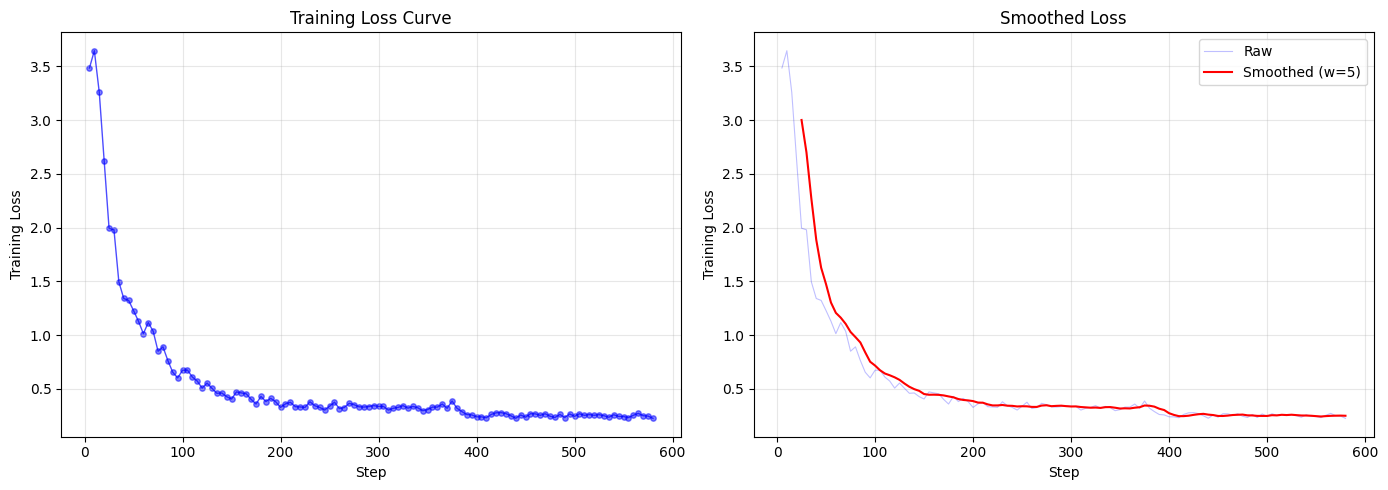

Loss 曲线已保存: ./roleplay-lora-extra/loss_curve.png
Loss: 3.4839 → 0.2271 (下降 3.2568)


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import glob

event_files = sorted(glob.glob(os.path.join(LOG_DIR, "**/events.out.tfevents.*"), recursive=True))
if not event_files:
    event_files = sorted(glob.glob(os.path.join(LOG_DIR, "events.out.tfevents.*")))

if not event_files:
    print("未找到 TensorBoard 日志，请确认训练已运行。")
else:
    event_file = event_files[0]
    print(f"读取日志: {event_file}")
    
    ea = EventAccumulator(event_file)
    ea.Reload()
    
    if "train/loss" not in ea.Tags()["scalars"]:
        print(f"可用 scalars: {ea.Tags()['scalars']}")
    else:
        train_loss = ea.Scalars("train/loss")
        steps = [s.step for s in train_loss]
        values = [s.value for s in train_loss]
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].plot(steps, values, "b-", alpha=0.7, linewidth=1)
        axes[0].scatter(steps, values, s=15, alpha=0.5, color="blue")
        axes[0].set_xlabel("Step")
        axes[0].set_ylabel("Training Loss")
        axes[0].set_title("Training Loss Curve")
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(steps, values, "b-", alpha=0.25, linewidth=0.8, label="Raw")
        if len(values) >= 5:
            window = min(5, len(values))
            smoothed = np.convolve(values, np.ones(window)/window, mode="valid")
            axes[1].plot(steps[window-1:], smoothed, "r-", linewidth=1.5, label=f"Smoothed (w={window})")
        axes[1].set_xlabel("Step")
        axes[1].set_ylabel("Training Loss")
        axes[1].set_title("Smoothed Loss")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "loss_curve.png"), dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Loss 曲线已保存: {OUTPUT_DIR}/loss_curve.png")
        print(f"Loss: {values[0]:.4f} → {values[-1]:.4f} (下降 {values[0]-values[-1]:.4f})")

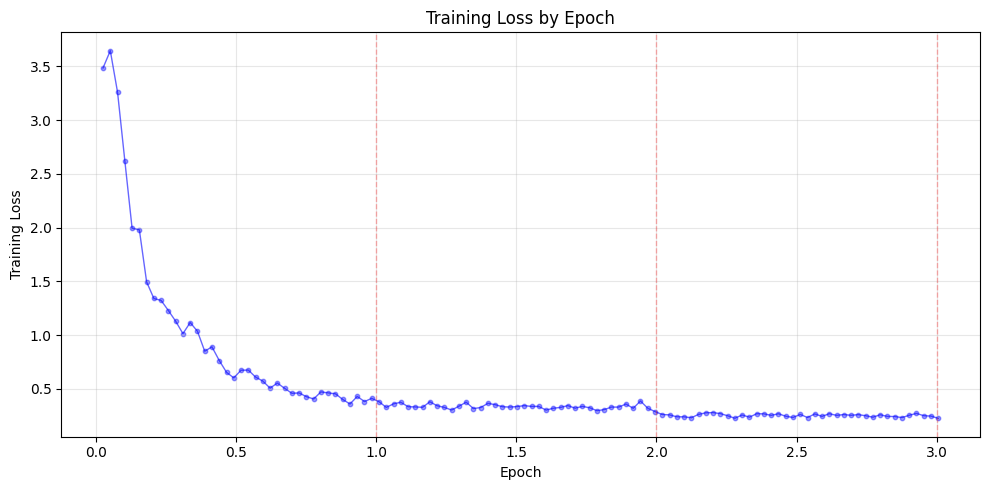

Epoch 曲线已保存: ./roleplay-lora-extra/loss_by_epoch.png


In [12]:
# per-epoch 可视化
if event_files and "train/loss" in ea.Tags()["scalars"]:
    steps_per_epoch = max(len(train_dataset) // (BATCH_SIZE * GRADIENT_ACCUMULATION), 1)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    epochs = [s / steps_per_epoch for s in steps]
    ax.plot(epochs, values, "b-", alpha=0.6, linewidth=1)
    ax.scatter(epochs, values, s=10, alpha=0.4, color="blue")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    ax.set_title("Training Loss by Epoch")
    ax.grid(True, alpha=0.3)
    
    for ep in range(1, NUM_EPOCHS + 1):
        ax.axvline(x=ep, color="red", linestyle="--", alpha=0.3, linewidth=1)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "loss_by_epoch.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Epoch 曲线已保存: {OUTPUT_DIR}/loss_by_epoch.png")

## 9. 推理测试

用训练过的 NPC 对话模型进行推理。

In [13]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

# 训练时的 model 来自 trust_remote_code 缓存代码，与 DynamicCache 不兼容。
# 重新加载 base model（不加 trust_remote_code，用本地内置 Phi3），再挂载 adapter。
print("重新加载模型（内置 Phi3 + LoRA adapter）...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.bfloat16,
    # 不加 trust_remote_code，避免 seen_tokens 兼容性问题
)
model = PeftModel.from_pretrained(model, final_model_path)
model.eval()

# 构造一个 NPC 角色（模仿 npc-dialogue 训练格式）
test_npc_bio = "Kael is a retired knight who now runs a small tavern. He is warm-hearted but weary from years of battle. He often dispenses life advice alongside drinks."

messages = [
    {"role": "system", "content": test_npc_bio},
    {"role": "user", "content": "What do you think about courage?"},
]

print("正在生成回复...")
inputs = tokenizer.apply_chat_template(
    messages, add_generation_prompt=True, return_tensors="pt"
).to(model.device)

with torch.no_grad():
    outputs = model.generate(
        inputs,
        max_new_tokens=150,
        temperature=0.8,
        top_p=0.9,
        do_sample=True,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.pad_token_id,
    )

response = tokenizer.decode(outputs[0][len(inputs[0]):], skip_special_tokens=True)
print(f"\n{'='*50}")
print(f"NPC: Kael (退休骑士/酒馆老板)")
print(f"游客: What do you think about courage?")
print(f"\nKael 回复:\n{response}")
print(f"{'='*50}")

重新加载模型（内置 Phi3 + LoRA adapter）...


Loading checkpoint shards: 100%|██████████| 2/2 [00:09<00:00,  4.69s/it]
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


正在生成回复...

NPC: Kael (退休骑士/酒馆老板)
游客: What do you think about courage?

Kael 回复:
Courage isn't the absence of fear, it's facing your worst nightmares head on and coming out victorious in spite of them.


## 10. 多轮对话测试

In [14]:
# 如果 model 还是训练时那个（trust_remote_code 缓存代码），重新加载
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

if not hasattr(model, 'peft_config') or 'DynamicCache' in str(type(getattr(model, 'base_model', None))):
    pass  # 已在上一个 cell 重新加载，可复用

def chat_turn(messages, user_input, max_new_tokens=150):
    messages.append({"role": "user", "content": user_input})
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt"
    ).to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.8,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.pad_token_id,
        )
    
    response = tokenizer.decode(outputs[0][len(inputs[0]):], skip_special_tokens=True)
    messages.append({"role": "assistant", "content": response})
    return messages, response

messages = [{"role": "system", "content": test_npc_bio}]

print("多轮对话测试\n")
print(f"NPC: Kael (退休骑士/酒馆老板)")
print("-" * 50)

test_inputs = [
    "What kind of drinks do you serve here?",
    "Tell me about your time as a knight.",
    "Any advice for someone who wants to become a warrior?",
]

for user_msg in test_inputs:
    print(f"\n🧑 游客: {user_msg}")
    messages, reply = chat_turn(messages, user_msg)
    print(f"🍺 Kael: {reply}")

多轮对话测试

NPC: Kael (退休骑士/酒馆老板)
--------------------------------------------------

🧑 游客: What kind of drinks do you serve here?
🍺 Kael: A variety, to suit all tastes and occasions!

🧑 游客: Tell me about your time as a knight.
🍺 Kael: I was proudly serving my kingdom until retirement came calling. Now it's just stories in this old inn.

🧑 游客: Any advice for someone who wants to become a warrior?
🍺 Kael: Patience: No one becomes a hero overnight. But passion will carry them through the darkest nightmares they face on their journey toward greatness. Always have hope at heart. That'll get 'em there fine. Just gotta take that first step strong, no matter how daunting or difficult may seem; always remember what keeps ya grounded when everything else feels like its pulling ye away. Keeping true north - yer own compass beats every bit. The path ain’t easy – plenty folks tryin', failures abound. Don't let ‘em discourage ya though. Stick with somethin'. Find solace where others find despair (even 

---

## 附录

### TensorBoard 实时监控

```bash
tensorboard --logdir ./roleplay-lora-extra/logs
```

### 断点续传

训练中断后，直接重新运行 **Section 6 的两个 cell** 即可自动从最新 checkpoint 恢复。

### Phi-3.5 vs Qwen 关键差异

| | Qwen2.5-1.5B | Phi-3.5-mini |
|---|---|---|
| 参数 | 1.5B | 3.8B |
| Chat 格式 | `<\|im_start\|>...<\|im_end\|>` | `<\|system\|>...<\|end\|>` |
| Attention | q/k/v/o_proj | qkv_proj, o_proj |
| MLP | gate/up/down_proj | gate_up_proj, down_proj |
| 数据集 | roleplay (5.7K) | npc-dialogue (1.7K) |
| 对话轮次 | 多轮 | 单轮 |
| 4-bit 显存 | ~1.5GB | ~2.5GB |